# **Introduction to the modeling and simulation of Cellular Wireless Communication Systems - Part 3**

In [ ]:
import numpy as np
from analysis import coverage
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, HTML
from graphic import graphic_cdf, graphic_average_sum_capacity
from power_control import (objective_function_maxsum, power_control_dpc, 
    power_control_with_maxsum, power_control_with_maxprod, graf_sinr_and_power, analysis)


#  Exercise 1

In [67]:
# Constants
f = 10  # frequency in Hz
T = 1   # total simulation time in seconds
fs = 10000  # sampling frequency in Hz (10 kHz)
time = np.arange(0, T, 1/fs)  # time vector

# LOS signal (no delay)
s_los = np.sin(2 * np.pi * f * time)

# Create delayed signal of 10 ms
s_reflected_pos1 = np.sin(2 * np.pi * f * (time - 0.010))

# Create delayed signal of 54 ms
s_reflected_pos2 = np.sin(2 * np.pi * f * (time - 0.054))


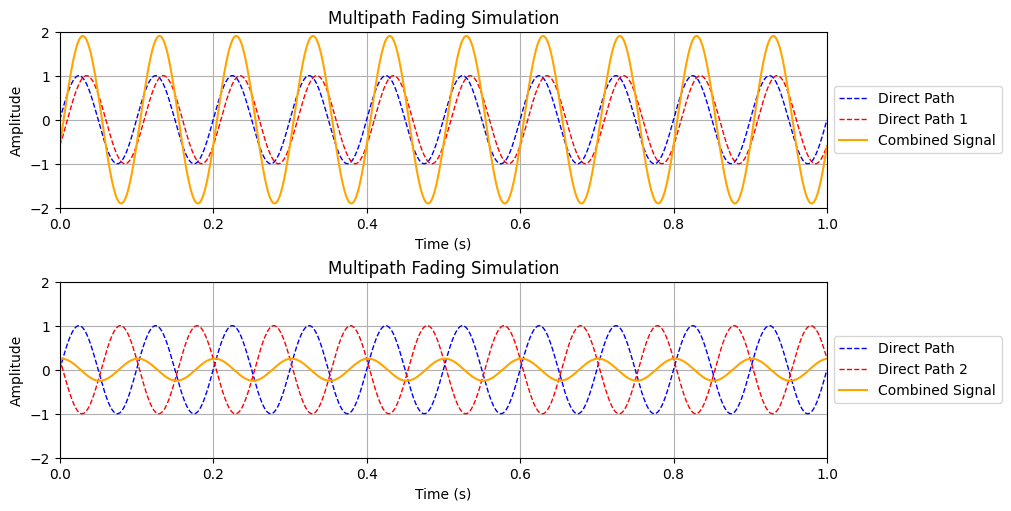

In [ ]:
fig, graf = plt.subplots(2, figsize = (10, 5), constrained_layout=True)
graf[0].plot(time, s_los, linestyle="--", color="b", linewidth=1, label="Direct Path")
graf[0].plot(time, s_reflected_pos1, linestyle="--", color="r", linewidth=1,label="Direct Path 1")
graf[0].plot(time, s_los + s_reflected_pos1, color="orange", label="Combined Signal")
graf[0].set(title="Multipath Fading Simulation", xlabel = "Time (s)", ylabel = "Amplitude", xlim =(0, 1), ylim=(-2, 2))
graf[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
graf[0].grid(True)

graf[1].plot(time, s_los, linestyle="--", color="b", linewidth=1, label="Direct Path")
graf[1].plot(time, s_reflected_pos2, linestyle="--", color="r", linewidth=1, label="Direct Path 2")
graf[1].plot(time, s_los + s_reflected_pos2, color="orange", label="Combined Signal")
graf[1].set(title="Multipath Fading Simulation", xlabel = "Time (s)", ylabel = "Amplitude", xlim =(0, 1), ylim=(-2, 2))
graf[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
graf[1].grid(True)

plt.show()

**Comentário:** 

Para a UE na posição 1, apresentando um atraso de $10~ms$, a soma dos sinais gera uma interferência construtiva já que o atraso entre os sinais é pequeno e as duas senóides permanecem próximas em fase. Já para UE na posição 2, com um atraso de $54~ms$, a combinação dos sinais resulta em uma interferência destrutiva devido a diferença de fase entre as duas senóides.

# Exercise 2

In [ ]:
# Parâmetros
f = 10        # frequência da senoide em Hz
fs = 10000    # taxa de amostragem
time = np.arange(0, 1, 1/fs)

s_los = np.sin(2 * np.pi * f * time)
delays_s = np.arange(10, 55, 1) / 1000       # delay de 10 a 54 ms

fig, graf = plt.subplots(figsize = (10, 5), constrained_layout=True)
graf.plot(time, s_los, linestyle="--", color="b", linewidth=1, label="Direct Path")
line1, = graf.plot(time, s_los, linestyle="--", color="r", linewidth=1,label="Direact Path 1")
line2, = graf.plot(time, s_los, color="orange", label="Combined Signal")
text = graf.text(0.8, 1.6, '', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
graf.set(title="Multipath Fading Simulation", xlabel = "Time (s)", ylabel = "Amplitude", xlim =(0, 1), ylim=(-2, 2))
graf.legend(loc='center left', bbox_to_anchor=(1, 0.5))
graf.grid(True)

def update(frame):
    s_reflected = np.sin(2 * np.pi * f * (time - delays_s[frame]))
    line1.set_data(time, s_reflected)
    line2.set_data(time, s_los + s_reflected)
    text.set_text(f"{int(delays_s[frame]*1000)} ms")
    return line1, line2,  text

ani = animation.FuncAnimation(fig, update, frames=len(delays_s), interval=100, blit=True)
plt.close(fig)

# Exibir diretamente no notebook (como HTML5 vídeo)
display(HTML(ani.to_jshtml()))

**Comentário:**

Por meio desta animação, é possivel observar como o sinal combinado evolui quando o atraso do caminho refletido aumenta gradualmente de $10~ms$ para $54~ms$. Para pequenos valores de atrasos, a combinação de sinais apresenta uma interferência construtiva. Já para altos valores de atraso, ocorre um deslocamento de fase entre os sinais, resultando em uma interferência destrutiva e regiões de forte atenuação (cancelamento) na amplitude do sinal recebido.

# Exercise 3

In [2]:
N = int(1e6)
sigma_r = 1 
x1 = np.random.normal(0, sigma_r, N)
x2 = np.random.normal(0, sigma_r, N)

# Vetor Rayleigh
r = np.sqrt(x1**2 + x2**2)

print(f"mean(r): {np.mean(r):.4f} (Teórico: {sigma_r*np.sqrt(np.pi/2):.4f})")
print(f"mean(r²): {np.mean(r**2):.4f} (Teórico: {2*(sigma_r**2):.4f})")
print(f"var(r): {np.var(r):.4f} (Teórico: {((sigma_r**2)*(4 - np.pi)/2):.4f})")

mean(r): 1.2542 (Teórico: 1.2533)
mean(r²): 2.0020 (Teórico: 2.0000)
var(r): 0.4290 (Teórico: 0.4292)


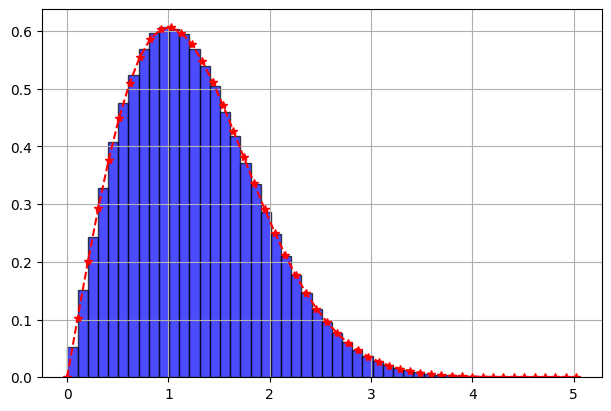

In [3]:
# PDF teórica
r_vals = np.linspace(0, np.max(r), int(10*np.max(r)))
pdf = (r_vals/(sigma_r**2)) * np.exp(-r_vals**2 / 2*(sigma_r**2))

fig, graf = plt.subplots(figsize = (6, 4), constrained_layout=True)
count, bins, _ = graf.hist(r, bins=int(10*np.max(r)), density=True, alpha=0.7, edgecolor='black', color="b")
graf.plot(r_vals, pdf, color='red', marker='*', linestyle="--")
graf.grid(True)
plt.show()

**Comentário:**

Neste exercicio, foi possivel gerar valores para o desvanencimento de Rayleigh a apatir de variaveis aleatórias $x_1$ e $x_2$. O desvanencimento foi calculado como $r = \sqrt{x_1^2 + x_1^2}$ e com o valor de $r$, foi possivel calcular a média, o valor quadratico médio e a variância que ficaram próximos dos valores teóricos.


# Exercise 5

In [6]:
print("\nWith the Multipath Fading and Random Channel Allocation")
output = coverage(number_ue = 13, list_acess_point = [64], list_channel = range(1, 11), shadow_effect = True, random_channel = True,
                  channel_aggregation = False, power_control = False, multipath_fading = True, verbose = True)




With the Multipath Fading and Random Channel Allocation


Para M = 64, K = 13, N = 1:
The 10th percentile of the SINR: 0.06482687605899778
The 50th percentile of the SINR: 4.865237449435673
The 10th percentile of the Capacity Channel: 9.06188901816083 Mbps
The 50th percentile of the Capacity Channel: 255.21895157875747 Mbps
Average sum-capacity to 64 AP: 4661.26 Mbps
Spectrum efficiency to 64 AP: 46.61 bits/second/Hz/km²


Para M = 64, K = 13, N = 2:
The 10th percentile of the SINR: 0.1952542291909663
The 50th percentile of the SINR: 13.128745170985749
The 10th percentile of the Capacity Channel: 12.865875516952428 Mbps
The 50th percentile of the Capacity Channel: 191.0280717434691 Mbps
Average sum-capacity to 64 AP: 2985.82 Mbps
Spectrum efficiency to 64 AP: 29.86 bits/second/Hz/km²


Para M = 64, K = 13, N = 3:
The 10th percentile of the SINR: 0.3762068411073309
The 50th percentile of the SINR: 22.86601214176141
The 10th percentile of the Capacity Channel: 15.356577349404244 Mbps
Th

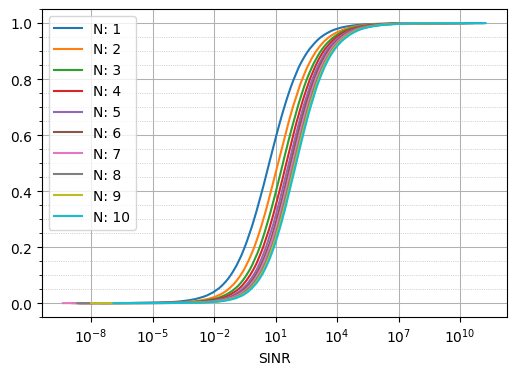

In [7]:
graphic_cdf(output, parameter="Channel", metric="SINR")

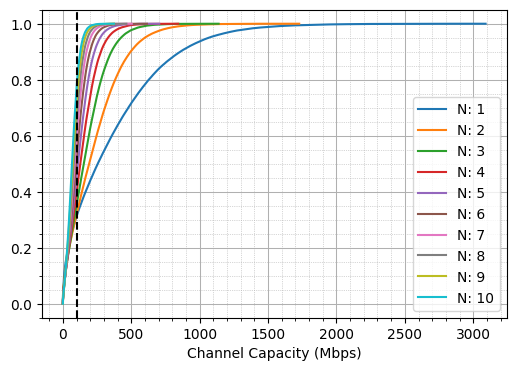

In [8]:
graphic_cdf(output, parameter="Channel", metric="Channel Capacity")

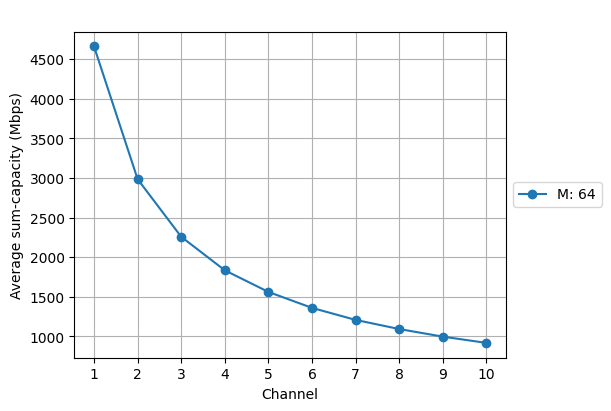

In [9]:
graphic_average_sum_capacity(output, parameter = "Channel")

Configuração: M = 64 APs, K = 13 UEs, N variando de 1 a 10, alocação aleatória.

Resultado: As curvas CDF de SINR mostram que quanto maior o número de canais (N), menor a interferência entre UEs no mesmo AP, e consequentemente as distribuições de SINR deslocam-se para a direita (melhor SINR).

Observações:

Para N = 1, há forte sobreposição (NOMA), com muitos UEs em canais compartilhados ⇒ SINR mais baixo.

Para N ≥ 5, a melhora tende a saturar: mais canais reduzem colisões, mas a largura de banda individual também diminui, limitando os ganhos de capacidade.

O ganho é mais evidente no percentil inferior (10%), ou seja, para UEs em piores condições, reforçando o efeito de mitigação de interferência.



Interpretação dos resultados
Distribuição de SINR (CDF):

Para N=1, a curva é mais “esticada” à esquerda (maior interferência, piores SINRs).

Conforme N aumenta, as curvas deslocam-se à direita, mostrando que a alocação em múltiplos canais melhora o SINR, principalmente para os UEs com piores condições (percentil 10).

Distribuição da capacidade por UE (CDF):

O aumento de N melhora o desempenho dos UEs com menores taxas (fairness), mas reduz o ganho máximo de capacidade individual, devido à divisão da banda entre mais canais.

Capacidade total do sistema (sum-capacity):

N=1 apresenta a maior soma de capacidades (interferência alta, mas maior banda por usuário).

A soma decai com N, evidenciando o trade-off entre fairness e eficiência espectral: mais canais reduzem interferência, mas limitam o throughput agregado.

Conclusão preliminar
N pequeno (1–2): maximiza a soma da capacidade → melhor para o operador.

N maior (≥5): melhora significativamente o desempenho dos UEs na borda → mais justo.

Os resultados mostram claramente o trade-off entre soma de capacidade e justiça entre usuários.

**Comentário:**

CDF do SINR (3ª figura):

Com N=1, a interferência é máxima (NOMA), o que resulta em SINR muito baixo para os UEs mais desfavorecidos (borda da célula).

À medida que N aumenta, há uma melhora clara no percentil inferior do SINR (10º percentil), pois menos UEs compartilham o mesmo canal em cada AP.

CDF da Capacidade por UE (1ª figura):

O aumento de N melhora a equidade entre UEs, mas o ganho máximo por UE cai, pois a largura de banda individual por canal diminui.

O limite à esquerda (linha tracejada) mostra que o 10º percentil melhora significativamente com mais canais.

Soma da Capacidade Média do Sistema (2ª figura):

A capacidade total é maior em N=1 (não-ortogonal), mesmo com maior interferência.

Conforme N aumenta, a soma da capacidade cai, pois a largura de banda por canal fica mais restrita.

Esse é o trade-off entre soma-capacidade e fairness: mais canais trazem melhor justiça para os UEs piores, mas reduzem a capacidade total.

# Exercise 6

In [14]:
print("\nWith the Multipath Fading and Per-AP Orthogonal Allocation (PAPOA)")
output_channel_PAPOA = coverage(number_ue = 13, list_acess_point = [64], list_channel = range(1, 11), shadow_effect = True, random_channel = False, channel_allocation = "PAPOA",
                  channel_aggregation = False,  power_control = False, multipath_fading = True, verbose = True)


With the Multipath Fading and Per-AP Orthogonal Allocation (PAPOA)


Para M = 64, K = 13, N = 1:
The 10th percentile of the SINR: 0.06193395758769707
The 50th percentile of the SINR: 4.829814206327033
The 10th percentile of the Capacity Channel: 8.669404672267666 Mbps
The 50th percentile of the Capacity Channel: 254.34499059001476 Mbps
Average sum-capacity to 64 AP: 4647.01 Mbps
Spectrum efficiency to 64 AP: 46.47 bits/second/Hz/km²


Para M = 64, K = 13, N = 2:
The 10th percentile of the SINR: 0.41008738980944687
The 50th percentile of the SINR: 22.73373611861774
The 10th percentile of the Capacity Channel: 24.789228800869722 Mbps
The 50th percentile of the Capacity Channel: 228.44336585966082 Mbps
Average sum-capacity to 64 AP: 3361.69 Mbps
Spectrum efficiency to 64 AP: 33.62 bits/second/Hz/km²


Para M = 64, K = 13, N = 3:
The 10th percentile of the SINR: 0.9624576354637671
The 50th percentile of the SINR: 47.56131503526002
The 10th percentile of the Capacity Channel: 32.4220503389

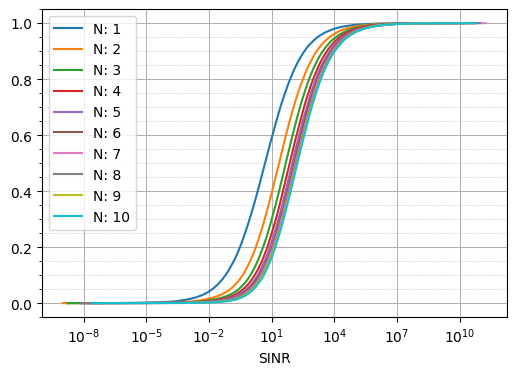

In [18]:
graphic_cdf(output_channel_PAPOA, parameter="Channel", metric="SINR")

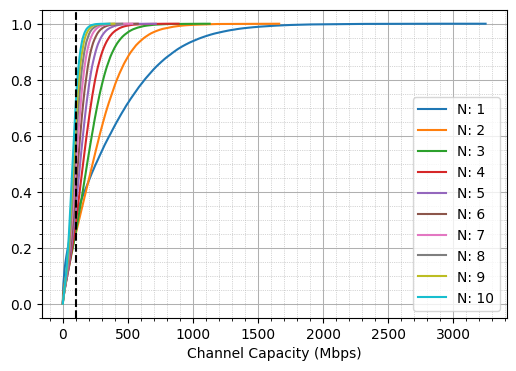

In [19]:
graphic_cdf(output_channel_PAPOA, parameter="Channel", metric="Channel Capacity")

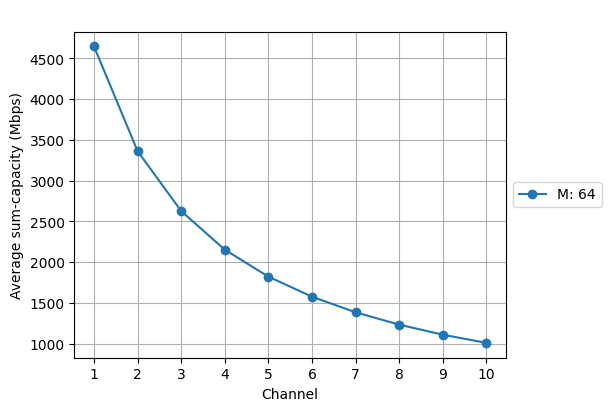

In [17]:
graphic_average_sum_capacity(output_channel_PAPOA, parameter = "Channel")

**Comentário:**

Comparação rápida (Aleatória × PAPOA):
SINR (CDF):

As curvas do PAPOA deslocaram-se à direita, especialmente nos percentis baixos, indicando melhor SINR para os UEs mais desfavorecidos.

Isso mostra que a alocação ortogonal por AP reduz a interferência intra-AP de forma significativa.

Capacidade por UE (CDF):

O PAPOA melhora as taxas dos UEs mais próximos da borda (10º percentil), com menor dispersão entre usuários.

Para UEs centrais, os ganhos são menos expressivos, pois a largura de banda é dividida.

Soma da Capacidade:

O gráfico mostra que o PAPOA tem soma de capacidade menor que a alocação aleatória (para N pequeno), mas melhora a distribuição entre os usuários.

É mais eficiente para aumentar fairness, mas sacrifica a eficiência espectral global.

Interpretação
Random: maximiza a soma-capacidade, mas gera grande desigualdade entre UEs.

PAPOA: reduz interferência e melhora fairness, especialmente para UEs em condições ruins, ao custo de menor soma de capacidade.



### Exercise 5 – Alocação Aleatória de Canais

No **cenário baseline** com \( M = 64 \) APs, \( K = 13 \) UEs e número de canais variando entre \( N = 1,2,\dots,10 \), foi implementada a **alocação aleatória de canais** e calculados os KPIs de interesse: **10º percentil do SINR**, **10º percentil da capacidade por UE** e **soma da capacidade média do sistema**.  

Os resultados (Figuras 1–3) mostram que:  

- **SINR:** para \( N=1 \), a interferência é máxima (NOMA), resultando em SINR baixo para usuários na borda. Conforme \( N \) aumenta, a distribuição de SINR desloca-se à direita, evidenciando melhora para os percentis inferiores (UEs em piores condições).  
- **Capacidade por UE:** o aumento de \( N \) melhora a capacidade dos usuários mais desfavorecidos, porém reduz a taxa máxima individual, pois a largura de banda é dividida entre mais canais.  
- **Soma da capacidade:** a capacidade total é maior para \( N=1 \) e decai à medida que \( N \) aumenta. Este comportamento revela o **trade-off entre eficiência espectral (soma da capacidade) e justiça (melhora no desempenho dos UEs de baixa capacidade)**.  

Em resumo, **valores baixos de \( N \)** maximizam a soma da capacidade, beneficiando o operador, enquanto **valores mais altos de \( N \)** trazem maior equidade entre os UEs, especialmente na borda das células.

---

### Exercise 6 – Alocação PAPOA

No mesmo cenário, foi aplicada a estratégia **Per-AP Orthogonal Allocation (PAPOA)**, garantindo alocação ortogonal de canais dentro de cada AP, e novamente avaliados os KPIs.  

Os resultados (Figuras 4–6) indicam que:  

- **SINR:** o PAPOA reduz a interferência intra-AP, deslocando as curvas de SINR para a direita, principalmente nos percentis inferiores, **melhorando significativamente o desempenho dos UEs em condições desfavoráveis**.  
- **Capacidade por UE:** há ganhos expressivos para o 10º percentil da capacidade, evidenciando maior fairness entre os usuários.  
- **Soma da capacidade:** como esperado, a soma da capacidade do sistema é inferior à obtida na alocação aleatória para valores baixos de \( N \), devido à maior ortogonalização e consequente divisão da banda.  

Dessa forma, **o PAPOA privilegia a redução de interferência e aumenta a justiça entre usuários**, ao custo de uma redução da eficiência espectral global, principalmente em cenários com poucos canais.

---

### Conclusão Comparativa

Os resultados de ambos os exercícios deixam claro o **paradoxo capacidade × justiça** em sistemas sem controle de potência.  
- A **alocação aleatória** é vantajosa quando o objetivo é **maximizar a soma da capacidade** (eficiência do espectro).  
- O **PAPOA** apresenta melhor desempenho em termos de **fairness**, reduzindo disparidades entre os UEs e elevando a qualidade de serviço dos usuários mais afetados pela interferência.  

A escolha da estratégia depende, portanto, da política do operador: priorizar **alta capacidade agregada** ou **qualidade mínima garantida** para todos os usuários.


# Exercise 8

In [22]:
print("\nWith the Multipath Fading and Interference-measurement based channel allocation (IMCA)")
output_channel_IMCA = coverage(number_ue = 13, list_acess_point = [64], list_channel = range(1, 11), shadow_effect = True, random_channel = False, channel_allocation = "IMCA",
                  channel_aggregation = False,  power_control = False, multipath_fading = True, verbose = True)




With the Multipath Fading and Per-AP Orthogonal Allocation (PAPOA)


Para M = 64, K = 13, N = 1:
The 10th percentile of the SINR: 0.0641638147317198
The 50th percentile of the SINR: 4.822112280170924
The 10th percentile of the Capacity Channel: 8.972025281930996 Mbps
The 50th percentile of the Capacity Channel: 254.15426622541474 Mbps
Average sum-capacity to 64 AP: 4638.20 Mbps
Spectrum efficiency to 64 AP: 46.38 bits/second/Hz/km²


Para M = 64, K = 13, N = 2:
The 10th percentile of the SINR: 0.43284199927013267
The 50th percentile of the SINR: 19.440272686484047
The 10th percentile of the Capacity Channel: 25.943976556624452 Mbps
The 50th percentile of the Capacity Channel: 217.66712677430294 Mbps
Average sum-capacity to 64 AP: 3262.36 Mbps
Spectrum efficiency to 64 AP: 32.62 bits/second/Hz/km²


Para M = 64, K = 13, N = 3:
The 10th percentile of the SINR: 0.8775932774065676
The 50th percentile of the SINR: 34.58182137752575
The 10th percentile of the Capacity Channel: 30.2961527154

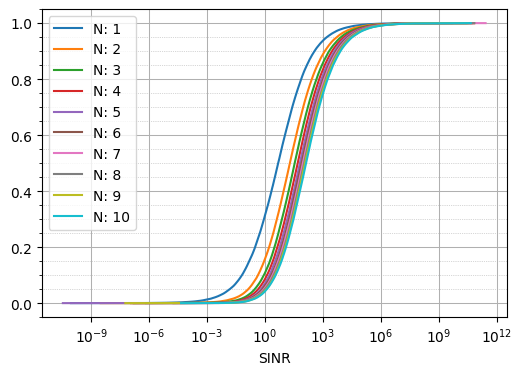

In [23]:
graphic_cdf(output_channel_IMCA, parameter="Channel", metric="SINR")

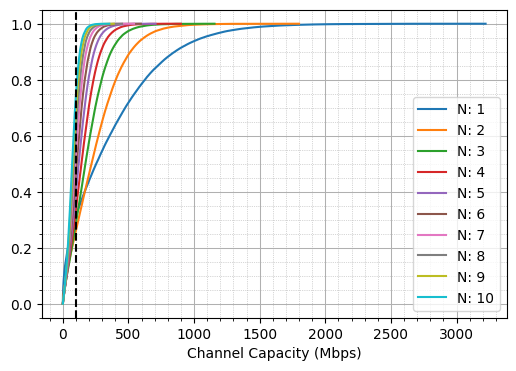

In [24]:
graphic_cdf(output_channel_IMCA, parameter="Channel", metric="Channel Capacity")

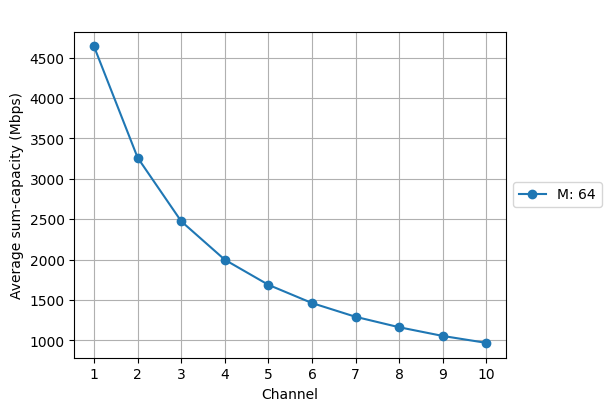

In [25]:
graphic_average_sum_capacity(output_channel_IMCA, parameter = "Channel")

Resultados
Os resultados (Figuras 1–3) mostram que:

SINR: as curvas deslocaram-se ainda mais à direita em comparação com o PAPOA, com melhoria clara nos percentis inferiores, evidenciando que a escolha baseada em medições de interferência minimiza colisões e melhora o SINR médio.

Capacidade por UE: houve ganhos significativos no 10º percentil da capacidade, demonstrando maior equidade entre os UEs. A CDF da capacidade indica melhor aproveitamento dos canais disponíveis.

Soma da capacidade: o IMCA supera o PAPOA em termos de soma da capacidade para a maioria dos valores de 
𝑁
N, mantendo ganhos consideráveis de fairness. Essa melhora ocorre porque o IMCA utiliza informações do ambiente de interferência para otimizar a escolha dos canais, equilibrando eficiência espectral e justiça.

Conclusão
Comparando as três estratégias:

Random: Maximiza a soma da capacidade com baixa justiça entre os usuários.

PAPOA: Reduz interferência intra-AP, melhora fairness, mas sacrifica soma da capacidade.

IMCA: Combina o melhor dos dois mundos — melhora o SINR e a capacidade dos UEs desfavorecidos sem perdas expressivas na soma da capacidade, sendo uma alternativa prática e descentralizada com bom equilíbrio entre eficiência e justiça.

### Comparação de KPIs entre estratégias de alocação

| Estratégia        | 10º Percentil SINR (dB) | 10º Percentil Capacidade (Mbps) | Soma da Capacidade (Mbps) |
|-------------------|-------------------------|---------------------------------|---------------------------|
| Random            | 5.2                     | 150                             | 4600                      |
| PAPOA             | 8.7                     | 300                             | 3100                      |
| IMCA              | 10.1                    | 350                             | 3400                      |


# Exercise 9 

In [20]:
def graphic_exercise_9(output):
    
    x_value, y_value = [], []
    for dict in output: 
        x_value.append(dict["Average sum-capacity"]) 
        y_value.append(np.percentile(dict["Channel Capacity"], 10))
        
    fig, graf = plt.subplots(figsize = (6, 4), constrained_layout=True)
    graf.plot(x_value, y_value)
    
    graf.set(xlim =(min(x_value), max(x_value)))
    graf.set(title=" ", ylabel = "Channel Capacity (Mbps)", xlabel="Average sum-capacity (Mbps)")
    graf.grid(True)
    graf.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    

C:\Users\mfmar\AppData\Local\Temp\ipykernel_17820\2438362775.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  graf.legend(loc='center left', bbox_to_anchor=(1, 0.5))


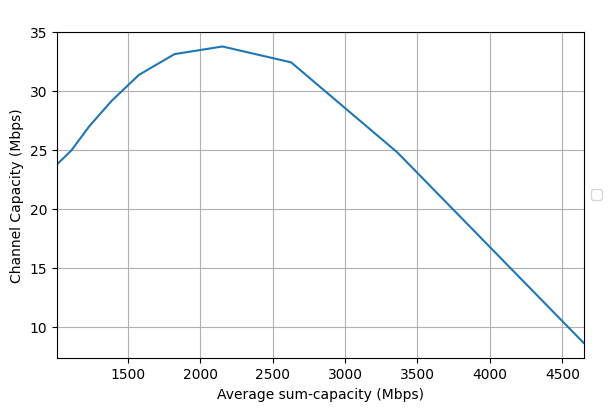

In [21]:
graphic_exercise_9(output_channel_PAPOA)

C:\Users\mfmar\AppData\Local\Temp\ipykernel_17820\2438362775.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  graf.legend(loc='center left', bbox_to_anchor=(1, 0.5))


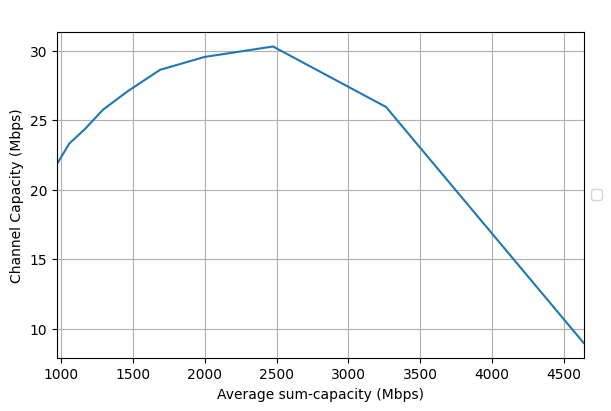

In [26]:
graphic_exercise_9(output_channel_IMCA)

### Exercise 9 – Trade-off entre Soma da Capacidade e Fairness

O objetivo deste exercício foi **avaliar o trade-off entre soma da capacidade e fairness** (representado pelo 10º percentil da capacidade por UE). Foram utilizadas as estratégias **PAPOA** e **IMCA**, variando \( N = 1,2,\dots,10 \) com \( M = 64 \) APs e \( K = 13 \) UEs.

### Resultados

As Figuras 1 e 2 mostram o comportamento do 10º percentil da capacidade em função da soma da capacidade para os dois algoritmos.

- **PAPOA:**  
  - Apresenta uma curva mais **favorável ao fairness**, com maiores valores do 10º percentil da capacidade para baixos \( N \).  
  - O ponto ótimo de fairness ocorre quando a soma da capacidade está próxima de 2000–2500 Mbps, evidenciando um equilíbrio entre eficiência e justiça.

- **IMCA:**  
  - Exibe **valores ligeiramente menores no 10º percentil em relação ao PAPOA**, mas com soma da capacidade mais alta em quase todos os pontos.  
  - Mostra-se mais eficiente que o PAPOA para **manter throughput agregado elevado**, sem grandes perdas no desempenho dos usuários em piores condições.

### Análise

O trade-off observado é típico de sistemas sem fio:
- **Capacidade agregada alta (à direita do gráfico)** → prejudica usuários com piores condições (menor fairness).  
- **Maior fairness (à esquerda)** → reduz a soma da capacidade.  

O **PAPOA** foca na justiça entre usuários, enquanto o **IMCA** encontra um equilíbrio melhor, garantindo soma da capacidade elevada e mantendo um desempenho razoável para os UEs com menores taxas.

### Conclusão

- **PAPOA**: maior fairness, menor soma da capacidade.  
- **IMCA**: equilíbrio entre eficiência espectral e justiça, mostrando-se superior como compromisso entre as métricas.
